# Unequal Environments, Unequal Health: Associations between Deprivation, Green Cover, and Year 6 Obesity across London MSOAs

## Preparation

- https://github.com/Levine-l/CASA0006_project

- Number of words: 1498

- Runtime: 1:31 Minutes (*System: Google Colab, Memory ~13 GB, CPU Intel(R) Xeon(R))*

- Coding environment: Python 3.12

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - geopandas(1.1.3): handling MSOA boundary geometries and spatial joins
    - statsmodels(0.14.6): OLS regression with HC3 robust standard errors and VIF diagnostics
    - libpysal(4.14.1): construction of spatial weights matrices
    - esda(2.9.0): calculation of Moran’s I for regression residuals

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Exploratory Analysis](#Exploratory-Analysis)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [Limitations](#Limitations)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Nowadays, childhood obesity remains a significant public health issue in England, especially among older primary school children. In 2023/24, Year 6 children obesity prevalence in England was 22.1%, with prevalence ranging from 29.2% in the most deprived areas to 13.0% in the least deprived. London is also among the regions with the highest Year 6 obesity prevalence, making it a ideal place to investigate spatial health inequalities (NHS England, 2024; Office for Health Improvement and Disparities, 2024).

Previous research suggests that childhood obesity has a clear spatial and neighbourhood dimension. Across England, obesity prevalence shows positive spatial dependence and is associated with socioeconomic disadvantage (Sun et al., 2020). Evidence also suggests that socioeconomic inequalities in child obesity may vary across ethnic groups (Goisis et al., 2019), while neighbourhood greenspace may also matter (Mears et al., 2020). Therefore, this project examines how Year 6 obesity prevalence across London MSOAs is associated with area deprivation, socio-demographic characteristics, and neighbourhood green cover.

## Research questions

[[ go back to the top ]](#Table-of-contents)

To what extent is Year 6 obesity prevalence across London MSOAs associated with area deprivation, socio-demographic composition, and neighbourhood green cover?

## Data

[[ go back to the top ]](#Table-of-contents)

#### **Data Introduction**

This project uses five datasets at MSOA level.

The dependent variable is taken from the [Prevalence of Childhood Obesity, Borough, Ward and MSOA](https://data.london.gov.uk/dataset/prevalence-of-childhood-obesity-borough-ward-and-msoa-23g07/) dataset from the London Datastore, which reports childhood weight outcomes for Reception and Year 6 pupils at multiple spatial scales, including MSOA.

Neighbourhood deprivation is measured using the [English Indices of Deprivation 2019](https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g/), and socio-demographic characteristics are drawn from the [2021 Census Bulk Data Download](https://www.nomisweb.co.uk/sources/census_2021_bulk), which includes census tables for MSOA such as ethnicity, housing tenure, education level, population density and household composition.

The environmental variable is based on the [Green Cover 2024](https://data.london.gov.uk/dataset/green-cover-2024-e56n0/) dataset, which provides estimates of green cover in London and related spatial layers. Finally, [London’s Statistical GIS Boundary Files](https://data.london.gov.uk/dataset/statistical-gis-boundary-files-for-london-20od9/) are used to support spatial referencing and mapping at MSOA level.

#### **Data Processing**

For child obesity prevalence data, extract from the worksheet 2011-12 to 2013-14, and only retain at MSOA level. A small number of missing values which may due to factors such as poor response rates and selective opt-outs, would handled through complete-case analysis during modelling (Information Centre for Health and Social Care, n.d.; Allison, 2001).

Deprivation data are using the IMD 2019, IDACI and IDAOPI, and Population figures sheets from the London IMD worksheet, and aggregated from 2011 LSOA to MSOA level using population weighted means.


Neighbourhood green cover was processed from the 2024 green cover polygon tiles, and spatial intersecting with London MSOA boundaries. Then calculate the total green cover area within each MSOA and converted into a percentage of the total MSOA area.

Socio-demographic covariates included population density, ethnic composition, housing tenure, unemployment and economic inactivity, qualifications, and household structure. Original counts are converted into percentages, and ethnic composition is represented by pct_non_white to reduce model multicollinearity.

Because the datasets used different geography boundary, Census 2021 and Green Cover data were harmonised to MSOA 2011 using official ONS lookups ([Best fit](https://www.data.gov.uk/dataset/9aa055b1-9b55-4d40-9be0-70bab8d55889/msoa-2011-to-msoa-2021-to-local-authority-district-2022-best-fit-lookup-for-ew-v21) & [exact fit](https://www.data.gov.uk/dataset/da36cac8-51c4-4d68-a4a9-37ac47d2a4ba/msoa-2011-to-msoa-2021-to-local-authority-district-2022-exact-fit-lookup-for-ew-v2)). The final dataset combined obesity, IMD, green cover, and census covariates on MSOA 2011 geography.

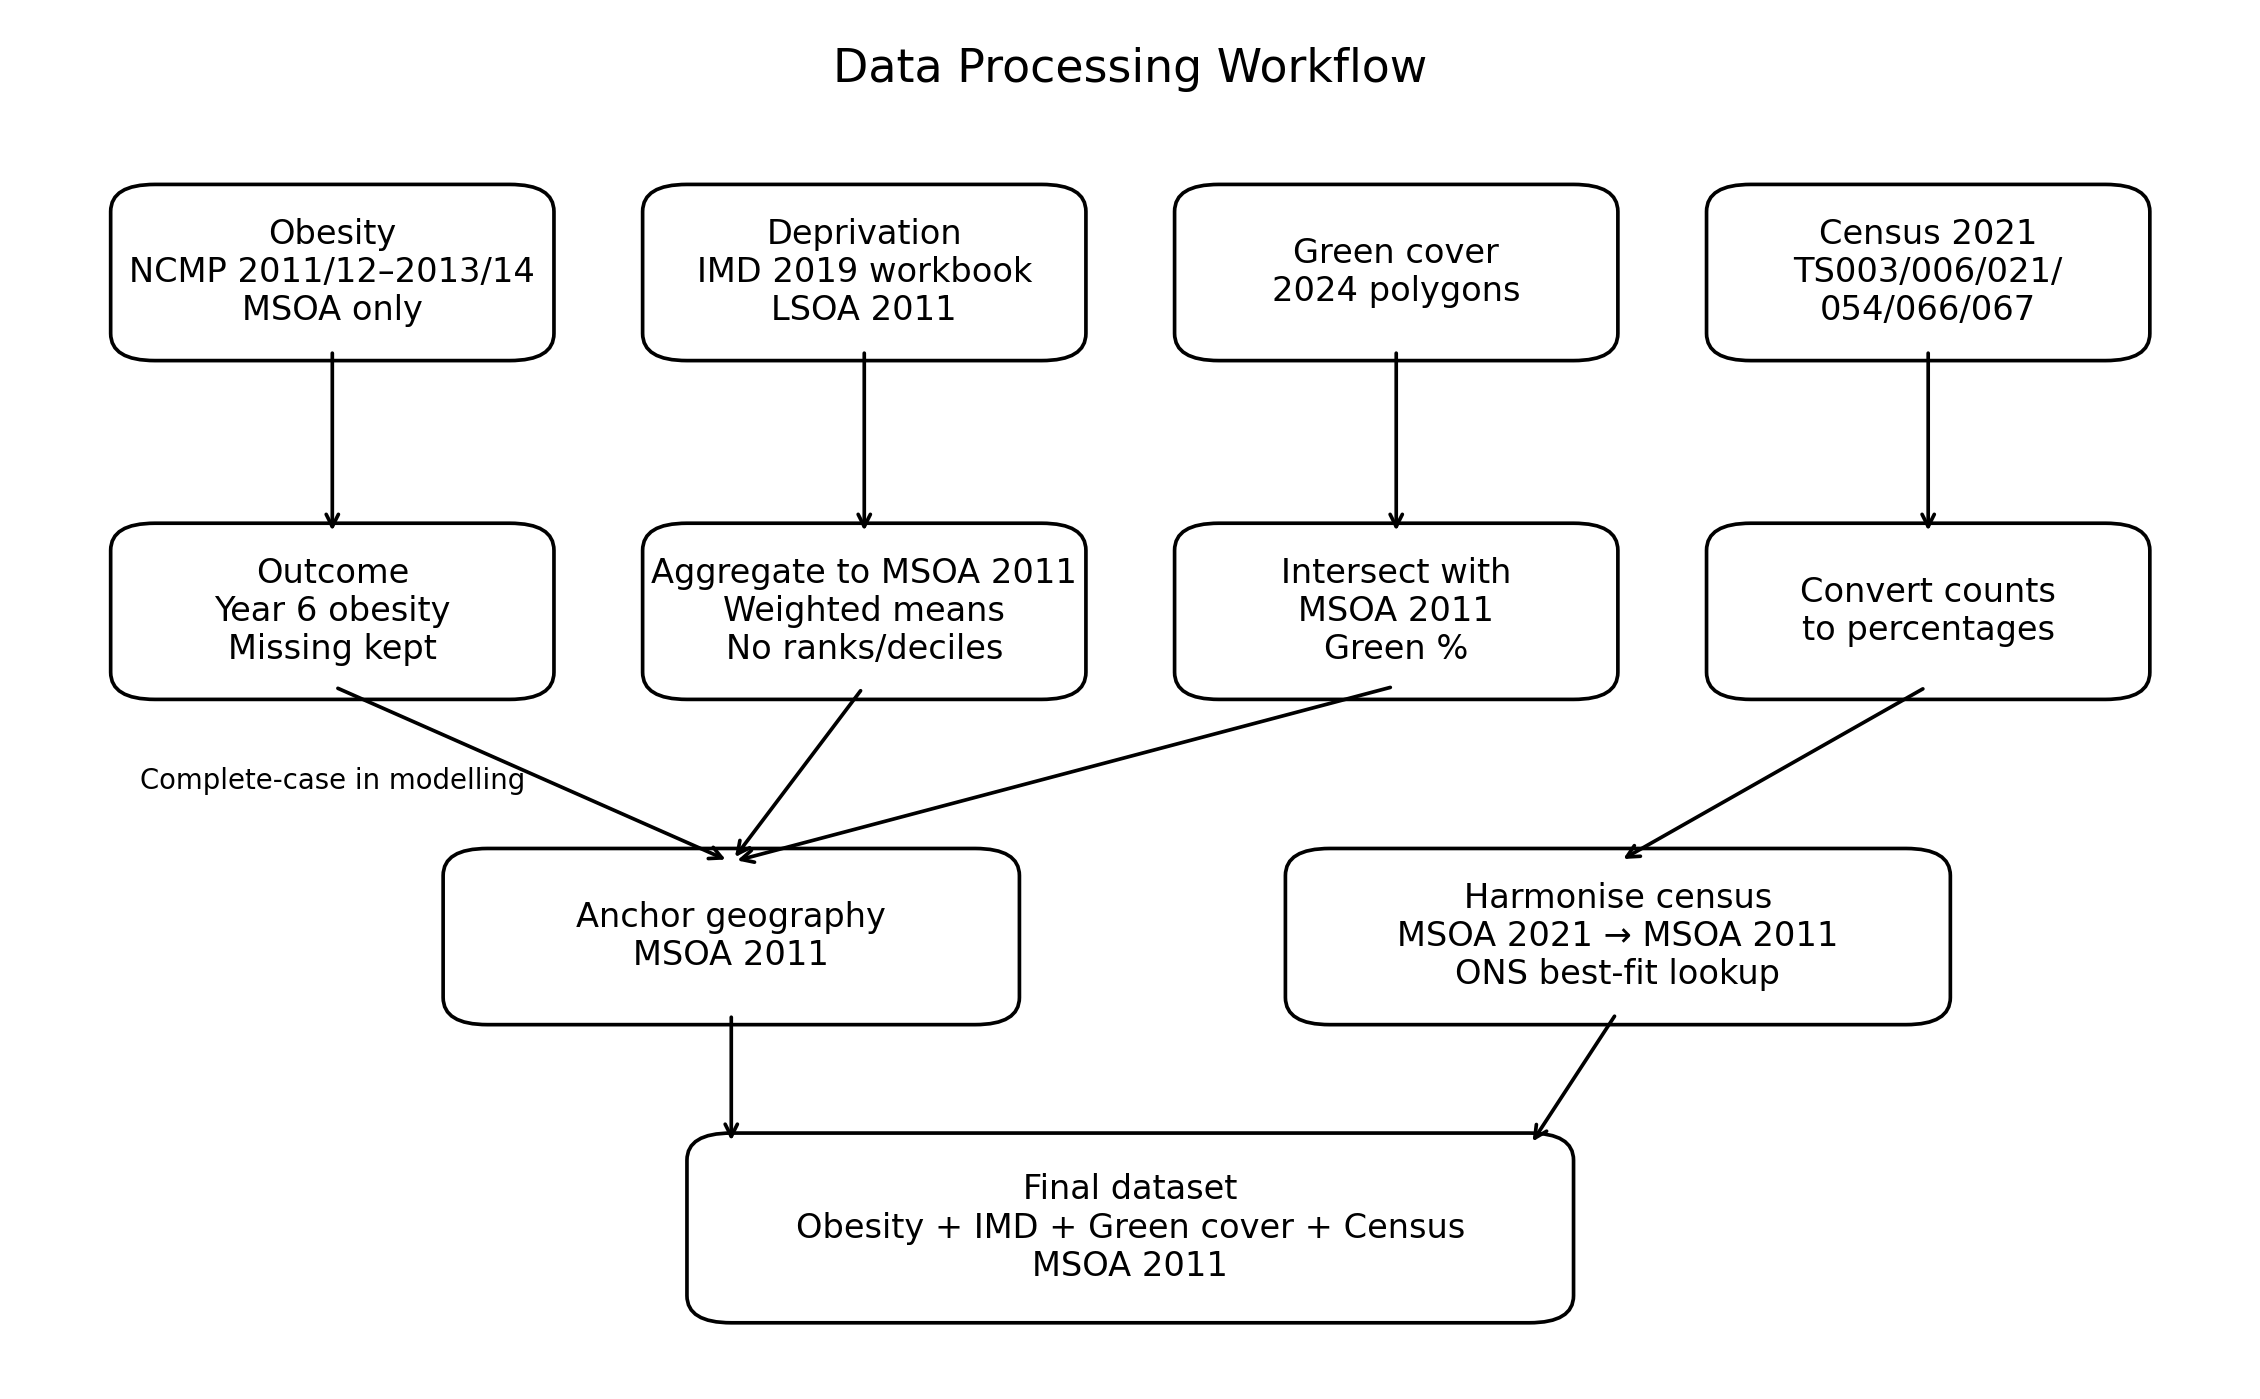

#### Variables used in the analysis

| Variable                                                                   | Type                     | Description                                                                                                      | Notes                                                                            |
| -------------------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| Year 6 obesity prevalence (`year6_obese_pct`)                              | Numeric                  | Percentage of Year 6 children classified as obese at MSOA level. Used as the dependent variable in the analysis. | Main outcome variable.                                                           |
| Green cover percentage (`green_cover_pct`)                                 | Numeric                  | Percentage of land area classified as green cover within each MSOA. Used as the main exposure variable.          | Main exposure of interest.                                                       |
| Index of Multiple Deprivation score (`imd_score_weighted`)                 | Numeric                  | Population-weighted IMD 2019 score at MSOA level, representing overall area deprivation.                         | Main deprivation measure used in the core models.                                |
| Income Deprivation Affecting Children Index score (`idaci_score_weighted`) | Numeric                  | Child-population-weighted IDACI score at MSOA level, reflecting deprivation affecting children.                  | Used in sensitivity analysis rather than the main model due to overlap with IMD. |
| Population density (`population_density_per_sqkm`)                         | Numeric                  | Number of residents per square kilometre in each MSOA.                                                           | Included as a socio-demographic control.                                         |
| Non-white population percentage (`pct_non_white`)                          | Numeric                  | Percentage of residents identifying as non-white in each MSOA.                                                   | Broad socio-demographic covariate used to reduce multicollinearity.              |
| Social rented housing percentage (`pct_social_rented`)                          | Numeric                  | Percentage of households living in socially rented accommodation in each MSOA.                                   | Socio-demographic covariate; may also reflect housing disadvantage.              |
| No qualifications percentage (`pct_no_qualifications`)                          | Numeric                  | Percentage of residents with no formal qualifications in each MSOA.                                              | Socio-demographic covariate.                                                     |
| Unemployment percentage (`pct_unemployed_16plus`)                               | Numeric                  | Percentage of residents aged 16+ who are unemployed in each MSOA.                                                | Socio-demographic covariate.                                                     |
| Lone-parent household percentage (`pct_lone_parent_households`)                 | Numeric                  | Percentage of households headed by a lone parent in each MSOA.                                                   | Socio-demographic covariate.                                                     |
| MSOA code (`MSOA_code`)                                                    | Categorical / Identifier | Unique code identifying each MSOA.                                                                               | Used for joining only.                |
| MSOA name (`MSOA_name`)                                                    | Categorical / Identifier | Name of each MSOA.                                                                                               | Used for reporting and mapping only.                |
| Local authority district name (`LAD_name`)                                 | Categorical / Identifier | Name of the local authority district containing the MSOA.                                                        |                  |
| Exact fit match count (`exactfit_match_count`)                             | Numeric      | Validation count for spatial matching.                  | Used for data checking only.        |

## Methodology

[[ go back to the top ]](#Table-of-contents)

#### **Analytical Strategy**

This project uses a cross-sectional, MSOA-level design to examine how London Year 6 obesity prevalence is associated with neighbourhood green cover, area deprivation, and selected socio-demographic characteristics. The dependent variable is year6_obese_pct. The main exposure element is green_cover_pct. Area deprivation is primarily measured using the population weighted IMD 2019 score (imd_score_weighted), while IDACI is for sensitivity analysis because of it is conceptually close with IMD.

#### **Exploratory Analysis**

EDA begins with descriptive and spatial exploratory analysis, using histograms, summary statistics, choropleth maps, scatterplots, and a correlation matrix to examine variable distributions, spatial patterning, and bivariate relationships across London MSOAs. This is intended to identify broad inequalities, motivate the later modelling strategy, and flag potential issues such as skewness and collinearity.


#### **Regression, Diagnostics, and Spatial checks**
The main inferential approach is hierarchical multivariable linear regression with HC3 robust standard errors.

Model 1 includes deprivation only. Model 2 adds selected socio-demographic covariates, including population density, ethnic composition, housing tenure, educational disadvantage, unemployment, and lone-parent household prevalence. Model 3 then adds green cover.
$$\text{Model 1: } y_i = \beta_0 + \beta_1 \text{IMD}_i + \varepsilon_i$$$$\text{Model 2: } y_i = \beta_0 + \beta_1 \text{IMD}_i + \beta'\mathbf{X}_i + \varepsilon_i$$$$\text{Model 3: } y_i = \beta_0 + \beta_1 \text{IMD}_i + \beta'\mathbf{X}_i + \beta_2 \text{GreenCover}_i + \varepsilon_i$$


($X_i$ includes selected socio-demographic covariates)


I assess multicollinearity using the correlation matrix and variance inflation factors, and exclude cases with missing values on model variables using complete-case analysis. None of the VIF values exceed commonly used rule-of-thumb thresholds for severe multicollinearity, often taken to be around 5 to 10, so the variables were retained, while overlapping disadvantage indicators were interpreted with care (Kim, 2019; O’Brien, 2007).

$$VIF_j = \frac{1}{1 - R_j^2}$$

Then residual spatial patterning in the fully adjusted model is examined using a residual choropleth and Moran’s I. Because Queen contiguity weights produced isolates for this geometry, Moran’s I was calculated using a centroid-based K-nearest-neighbours weights matrix (k = 8) as an alternative specification, this is consistent with Anselin (2020), who notes that isolates can be problematic for spatial analysis.

#### **Sensitivity Analysis and Comparison Model**

The sensitivity analysis aim to test whether the findings depend on how deprivation is measured by replacing imd_score_weighted with idaci_score_weighted. Besides, random forest is included as a supplementary comparison model to assess if variable importance rankings are consistent under a non-linear specification.



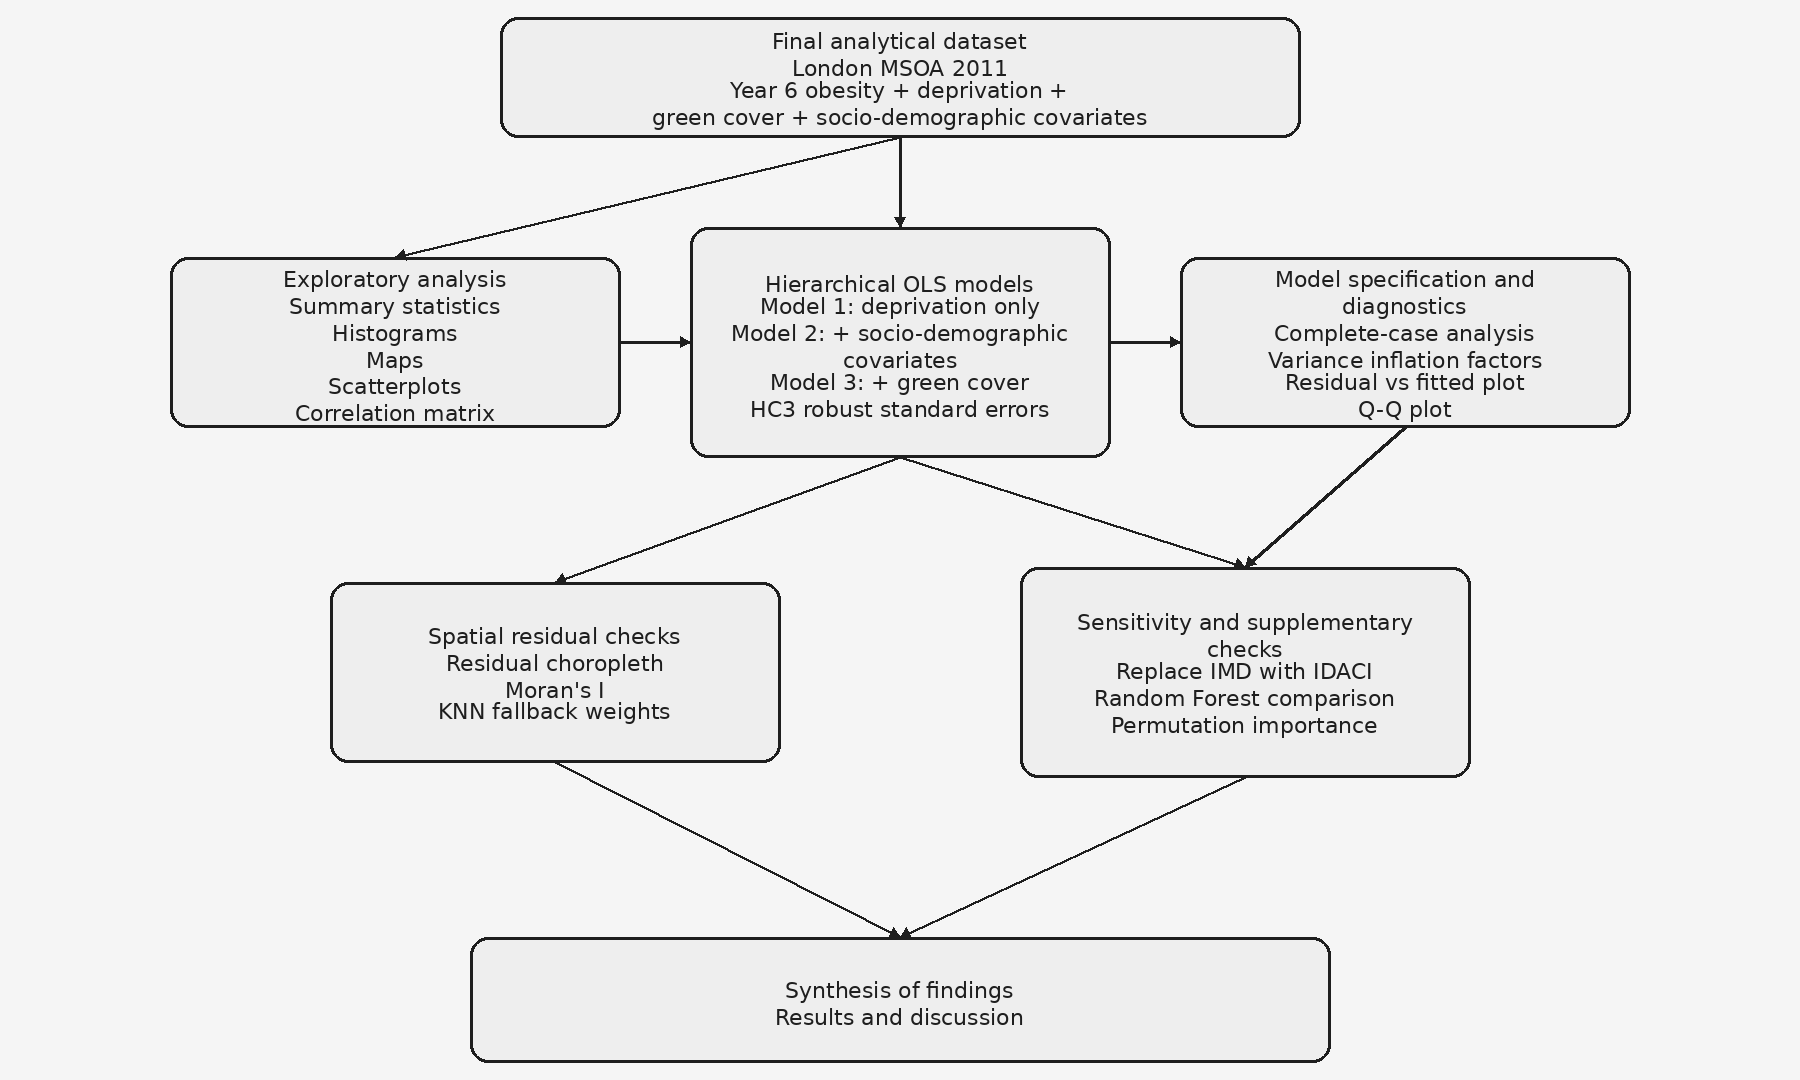

## Exploratory Analysis
[[ go back to the top ]](#Table-of-contents)

#### Loading data

In [1]:
from pathlib import Path
import geopandas as gpd
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

#plotting style and resolution
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

#path from the github
data_path = "https://raw.githubusercontent.com/Levine-l/CASA0006_project/main/london_obe_analysis.csv"
boundary_path = "https://raw.githubusercontent.com/Levine-l/CASA0006_project/main/msoa_2011/MSOA_2011_London_gen_MHW.shp"

#variables to be used in the regression analysis
eda_vars = [
    "MSOA_code",
    "MSOA_name",
    "LAD_name",
    "year6_obese_pct",
    "imd_score_weighted",
    "green_cover_pct",
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#load the main analysis dataset from GitHub
analysis = pd.read_csv(data_path)
#make sure MSOA codes are strings and stripped of whitespace for accurate merging
analysis["MSOA_code"] = analysis["MSOA_code"].astype(str).str.strip()

#load the London MSOA 2011 boundary
boundary = gpd.read_file(boundary_path)[["MSOA11CD", "MSOA11NM", "LAD11NM", "geometry"]].copy()
#rename boundary columns to match the main dataset identifiers
boundary = boundary.rename(
    columns={
        "MSOA11CD": "MSOA_code",
        "MSOA11NM": "MSOA_name_boundary",
        "LAD11NM": "LAD_name_boundary",
    }
)
boundary["MSOA_code"] = boundary["MSOA_code"].astype(str).str.strip()

#validate that all required core variables are present in the loaded dataset
missing_vars = [col for col in eda_vars if col not in analysis.columns]
if missing_vars:
    raise KeyError(f"Missing expected columns in harmonised dataset: {missing_vars}")

#create a subset of data for eda
eda = analysis[eda_vars].copy()
#merge analysis data with spatial boundaries for mapping
eda_map = boundary.merge(eda, on="MSOA_code", how="left")

#print summary of loaded data
print(f"Analysis data: {analysis.shape[0]} rows x {analysis.shape[1]} columns")
print(f"Boundary data: {boundary.shape[0]} MSOAs")
print(f"Records with obesity data after spatial merge: {eda_map['year6_obese_pct'].notna().sum()}")

Analysis data: 983 rows x 61 columns
Boundary data: 983 MSOAs
Records with obesity data after spatial merge: 959


#### 1. Data Overview

In [2]:
#calculate and display missing values for each variable
missingness = pd.DataFrame({
    "variable": eda_vars,
    "missing_n": [eda[col].isna().sum() for col in eda_vars],
})
missingness["missing_pct"] = (missingness["missing_n"] / len(eda) * 100).round(2)
missingness = missingness.sort_values(["missing_pct", "variable"], ascending=[False, True]).reset_index(drop=True)

#show the missingness summary table
display(missingness)

#define the subset of numeric variables
summary_vars = [
    "year6_obese_pct",
    "imd_score_weighted",
    "green_cover_pct",
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#descriptive statistics for the chosen variables
summary_table = eda[summary_vars].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
summary_table = summary_table.round(2)

#display summary statistics table
display(summary_table)

,variable,missing_n,missing_pct
0,year6_obese_pct,24,2.44
1,LAD_name,0,0.00
2,MSOA_code,0,0.00
3,MSOA_name,0,0.00
4,green_cover_pct,0,0.00
5,imd_score_weighted,0,0.00
6,pct_lone_parent_households,0,0.00
7,pct_no_qualifications,0,0.00
8,pct_non_white,0,0.00
9,pct_social_rented,0,0.00


,count,mean,std,min,25%,50%,75%,max
year6_obese_pct,959.0,21.83,5.46,5.63,18.46,22.58,25.80,39.68
imd_score_weighted,983.0,21.50,9.34,4.04,13.77,21.02,28.58,49.74
green_cover_pct,983.0,39.36,16.16,3.18,27.13,37.81,48.79,92.67
population_density_per_sqkm,983.0,8846.13,4966.55,302.30,5019.20,7896.30,12042.05,23873.40
pct_non_white,983.0,45.01,17.51,6.62,30.86,43.61,57.49,96.02
pct_social_rented,983.0,22.66,15.00,1.32,10.43,19.54,32.39,72.59
pct_no_qualifications,983.0,16.18,5.60,4.67,11.69,15.86,20.16,33.79
pct_unemployed_16plus,983.0,4.77,1.30,1.70,3.71,4.77,5.70,9.16
pct_lone_parent_households,983.0,13.33,4.82,3.56,9.74,12.61,16.33,33.09


Only Y6 obesity data has a few missing values.

#### 2. Histogram of Y6 Obesity Prevalence

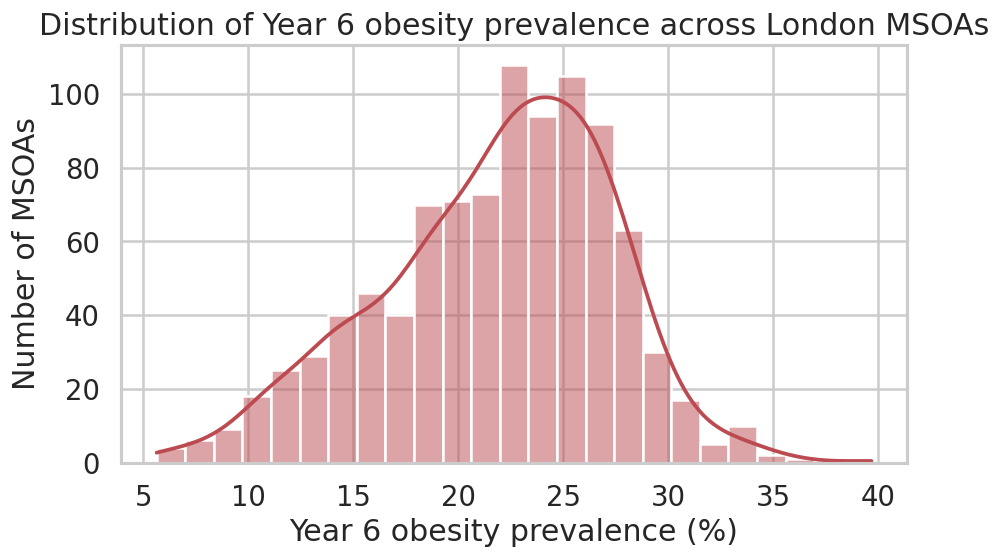

In [3]:
#figure size for the plot
fig, ax = plt.subplots(figsize=(8, 5))

#histogram where x is the Year 6 obesity percentage and y is the number of msoa
#with a kernel density estimate curve plot
sns.histplot(data=eda, x="year6_obese_pct", bins=25, kde=True, color="#bc4b51", edgecolor="white", ax=ax)

ax.set_title("Distribution of Year 6 obesity prevalence across London MSOAs")
ax.set_xlabel("Year 6 obesity prevalence (%)")
ax.set_ylabel("Number of MSOAs")

#adjust layout
fig.tight_layout()

# Display the plot in the notebook output
plt.show()

The distribution of Year 6 obesity prevalence is concentrated between 15% and 30%, with a modal peak at approximately 24%. While a small number of MSOAs exhibit relatively low or high prevalence, but there is no obvious skew in the overall distribution.

#### 3. Choropleth Map

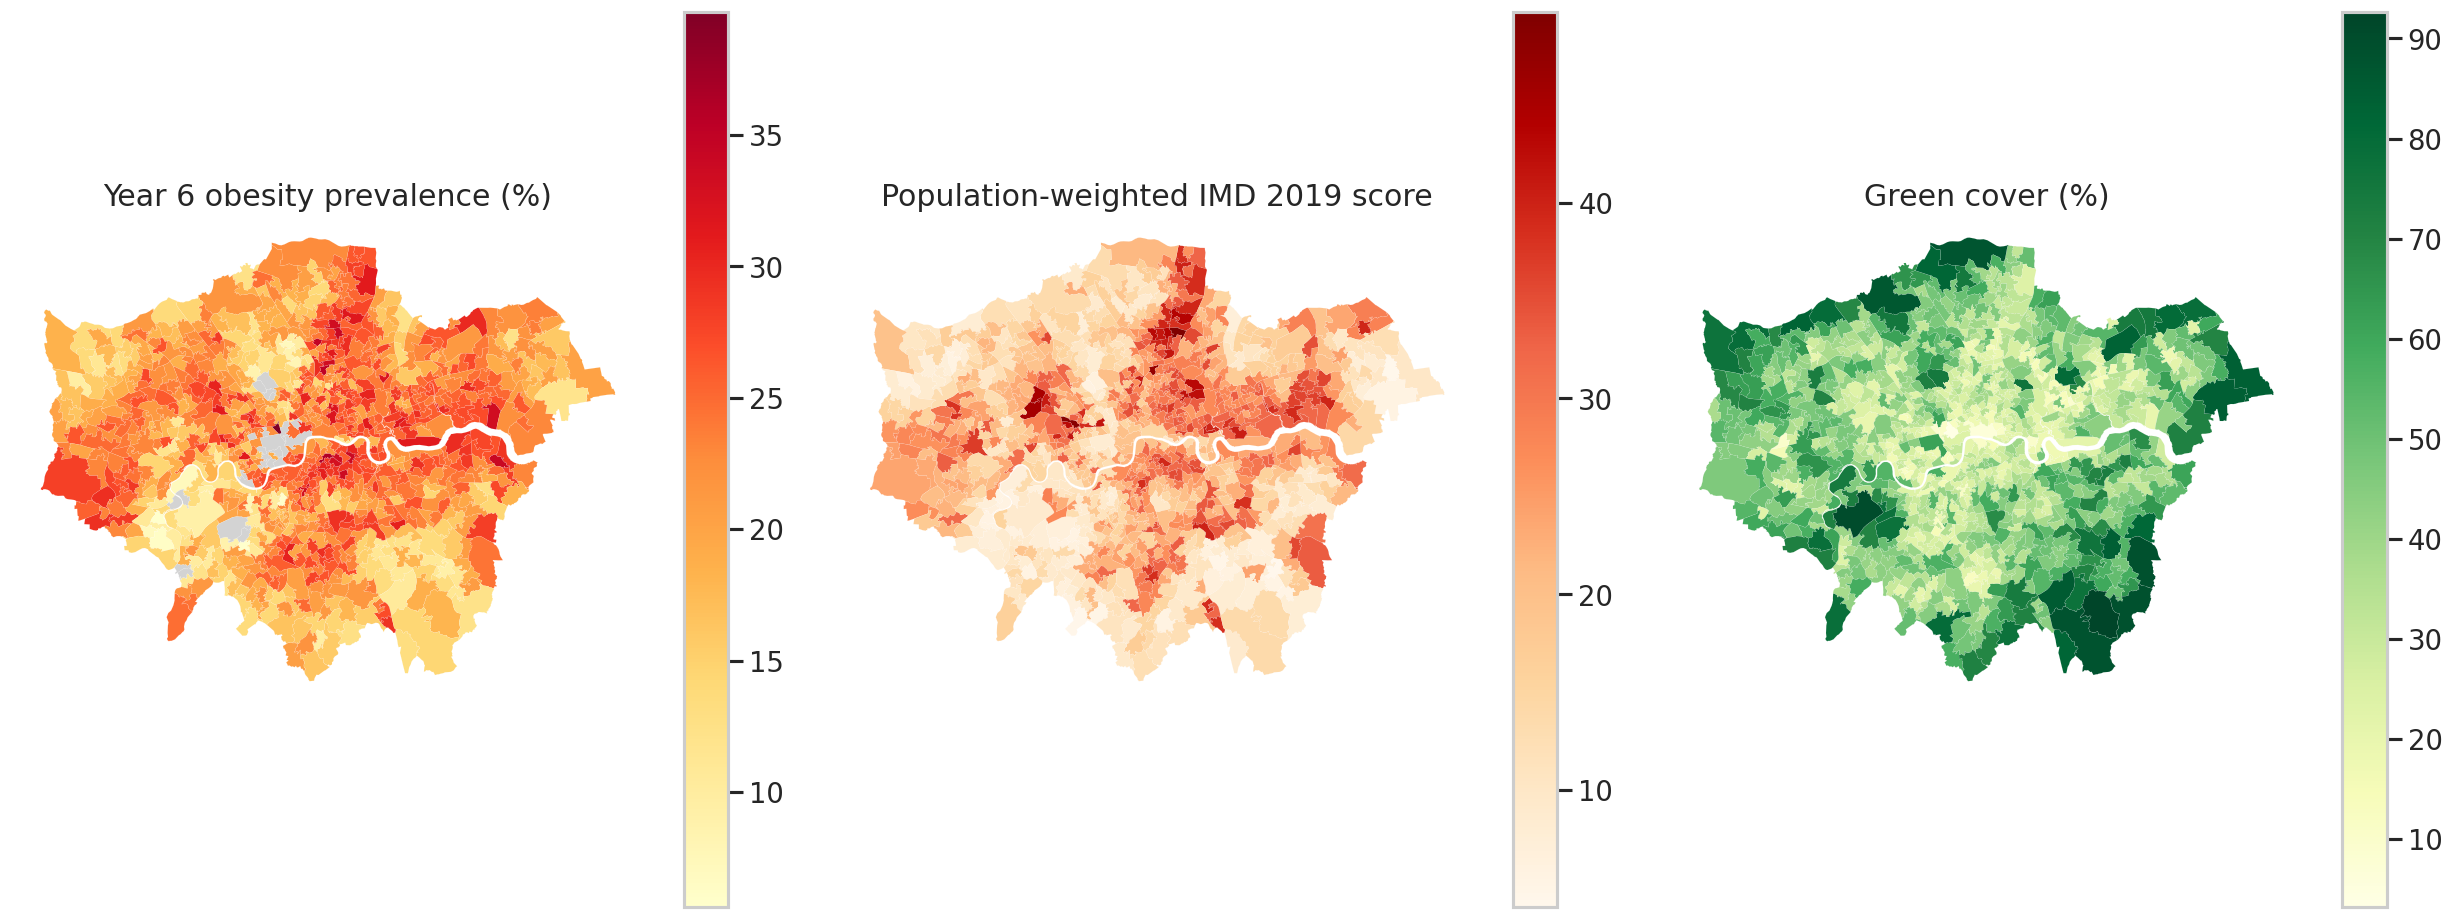

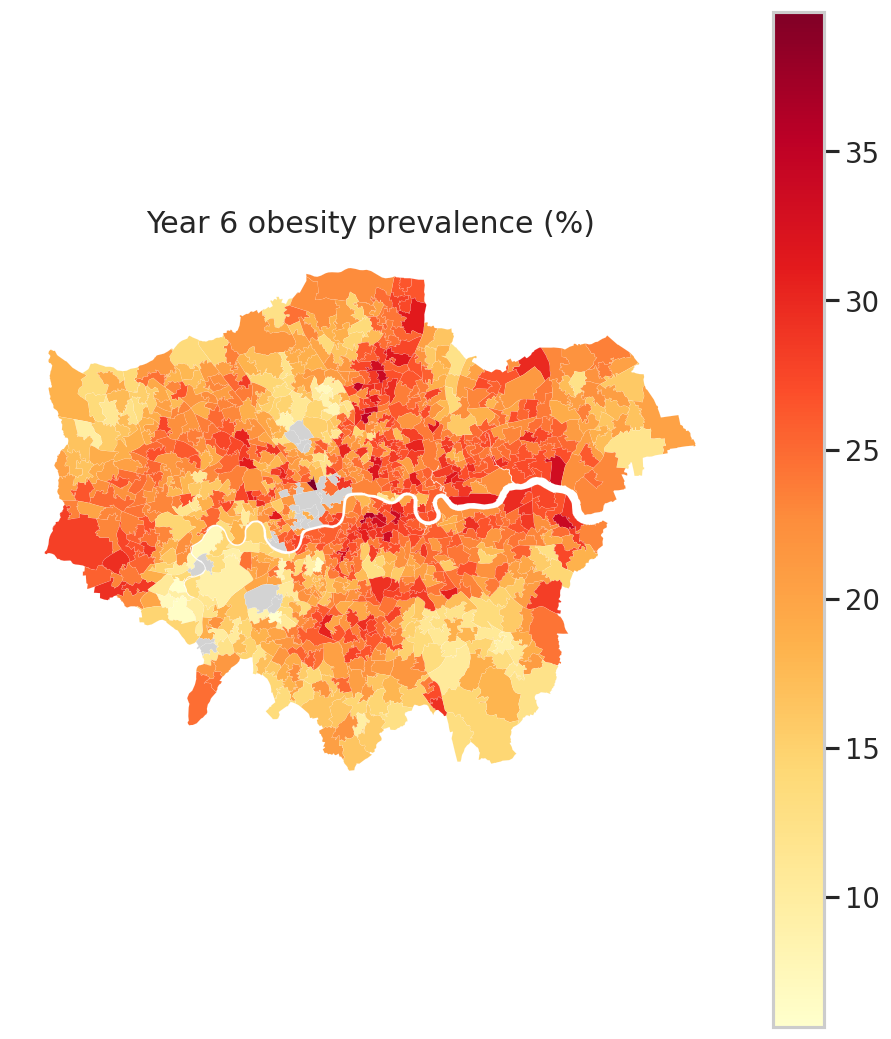

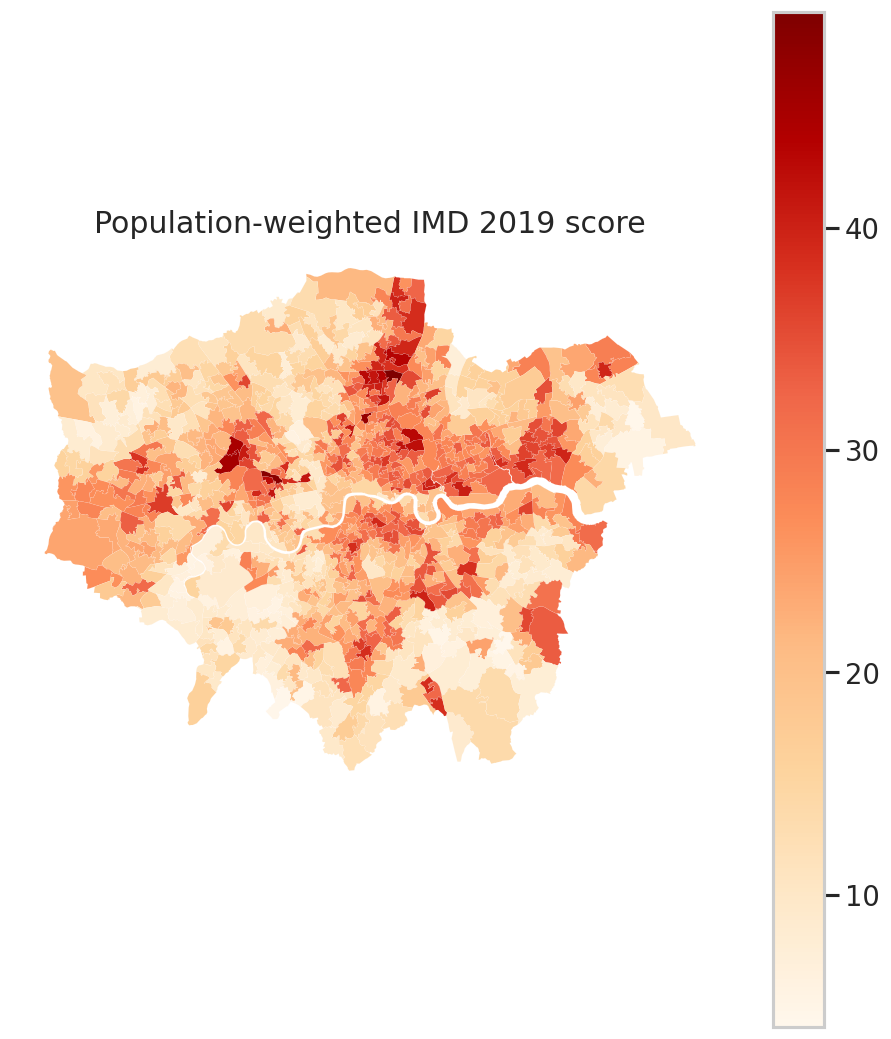

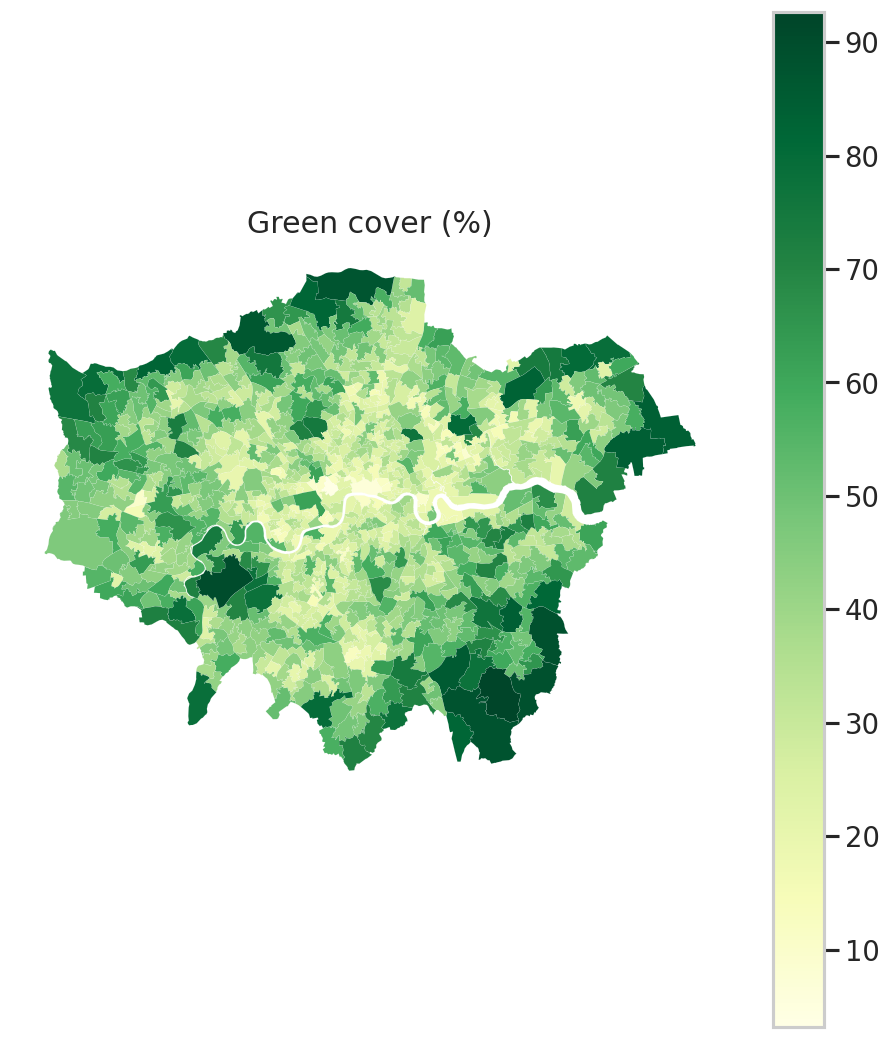

In [4]:
#define the map settings
map_specs = [
    ("year6_obese_pct", "Year 6 obesity prevalence (%)", "YlOrRd"),
    ("imd_score_weighted", "Population-weighted IMD 2019 score", "OrRd"),
    ("green_cover_pct", "Green cover (%)", "YlGn"),
]

#combined 3 plot figure for overview
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

#plot the choropleth map
for ax, (column, title, cmap) in zip(axes, map_specs):
    eda_map.plot(
        column=column,
        cmap=cmap,
        linewidth=0.05,
        edgecolor="white",
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "Missing"}, #dealing MSOAs with no data
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off() #hide x y coordinates

fig.tight_layout()
plt.show()

#create larger individual maps
for column, title, cmap in map_specs:
    fig, ax = plt.subplots(figsize=(8, 9))
    eda_map.plot(
        column=column,
        cmap=cmap,
        linewidth=0.05,
        edgecolor="white",
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "Missing"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()

The maps show that obesity and deprivation got a similar spatial pattern, while green cover is more concentrated in outer London.

#### 4. Key Scatterplots

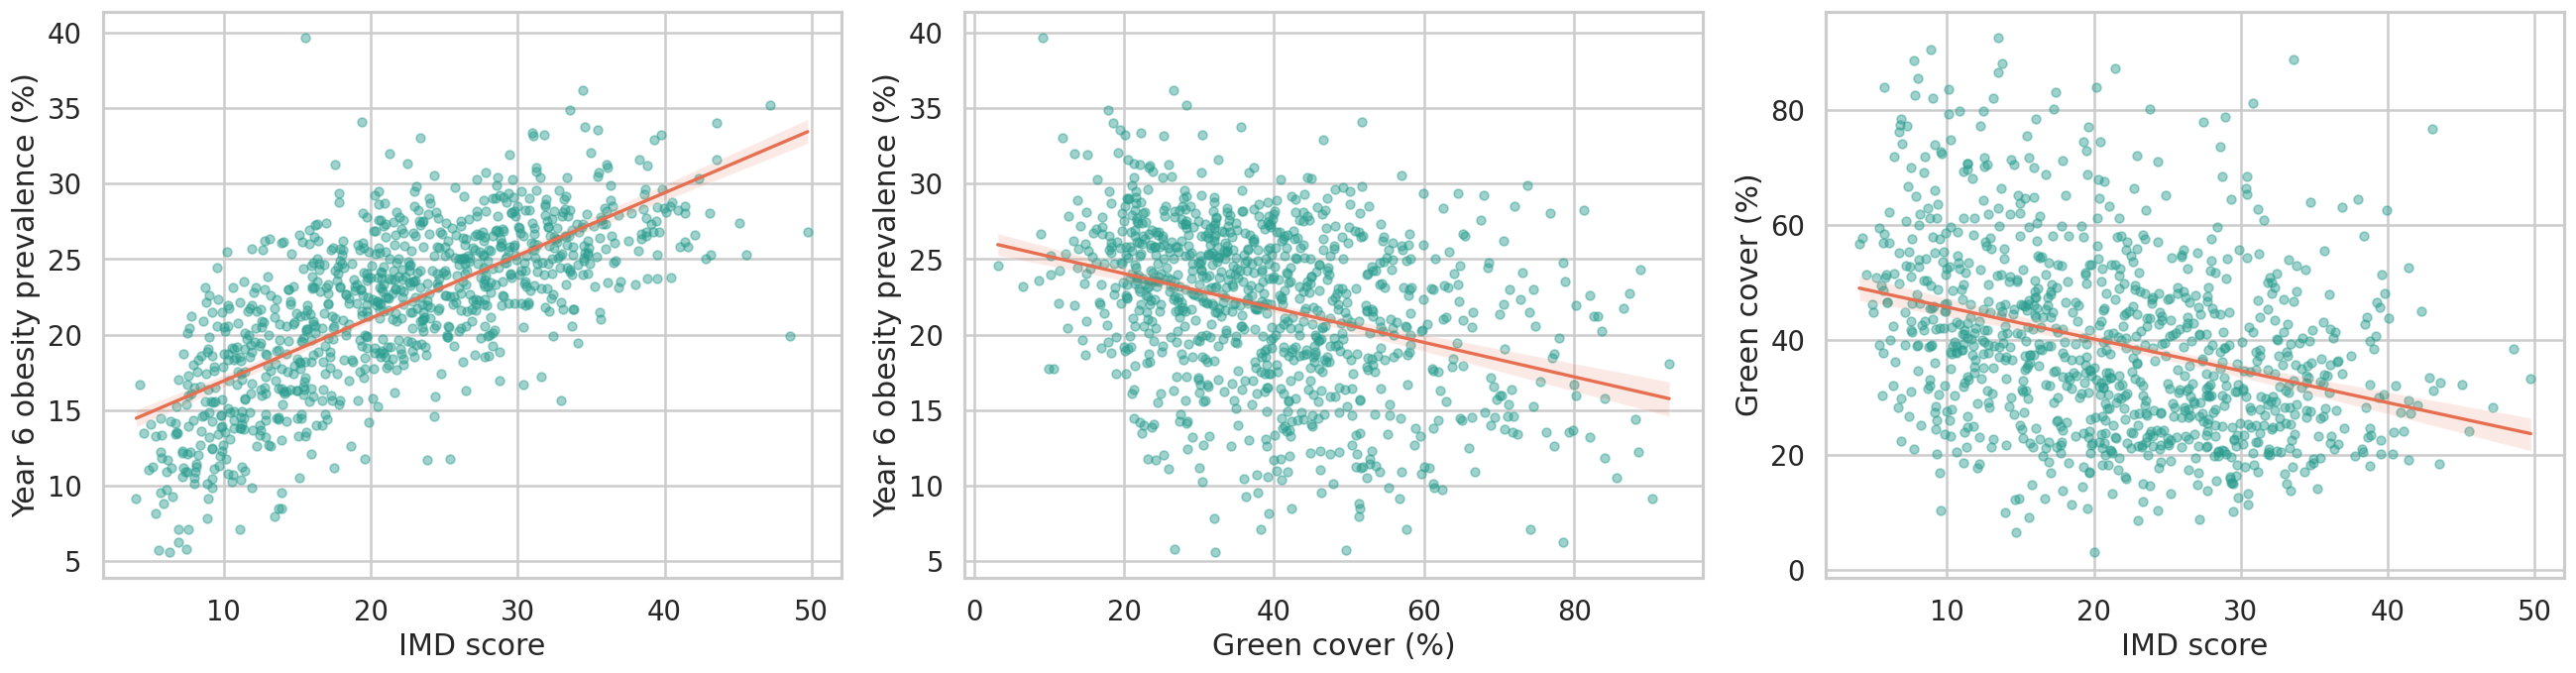

In [5]:
#define the scatterplot pairs
scatter_specs = [
    ("imd_score_weighted", "year6_obese_pct", "IMD score", "Year 6 obesity prevalence (%)"),
    ("green_cover_pct", "year6_obese_pct", "Green cover (%)", "Year 6 obesity prevalence (%)"),
    ("imd_score_weighted", "green_cover_pct", "IMD score", "Green cover (%)"),
]

#a multi-plot figure for key bivariate relationships
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (x_var, y_var, x_label, y_label) in zip(axes, scatter_specs):
    plot_df = eda[[x_var, y_var]].dropna().copy()#drop missing values

    #seaborn regplot to show scatter points and fitted linear regression line
    sns.regplot(
        data=plot_df,
        x=x_var,
        y=y_var,
        scatter_kws={"alpha": 0.45, "s": 28, "color": "#2a9d8f"}, #point's transparency and size
        line_kws={"color": "#e76f51", "lw": 2}, #regression line appearance
        ax=ax,
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

#adjust layout
fig.tight_layout()
plt.show()

#### 5. Correlation Heatmap

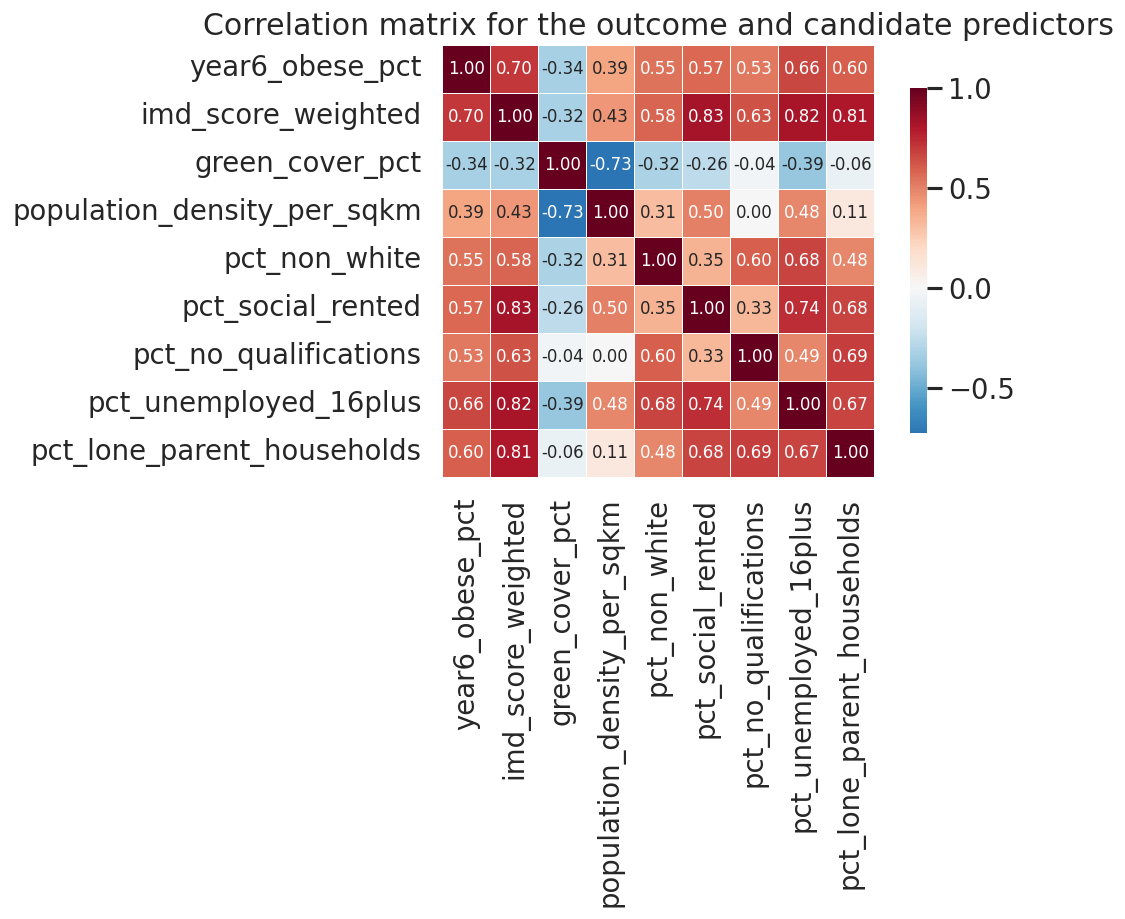

,correlation_with_year6_obese_pct
year6_obese_pct,1.000000
imd_score_weighted,0.704459
pct_unemployed_16plus,0.664553
pct_lone_parent_households,0.598388
pct_social_rented,0.574534
pct_non_white,0.546697
pct_no_qualifications,0.525397
population_density_per_sqkm,0.394047
green_cover_pct,-0.336009


In [6]:
#variables for the correlation analysis
heatmap_vars = [
    "year6_obese_pct",
    "imd_score_weighted",
    "green_cover_pct",
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#compute Pearson correlation matrix
corr_df = eda[heatmap_vars].copy()
corr_matrix = corr_df.corr(numeric_only=True)

#the heatmap visualization
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="RdBu_r", #red-blue color map
    center=0,
    annot=True, #print the correlation coefficients in each cell
    annot_kws={"size": 10},#aadjust the size of numbers
    fmt=".2f",#format coefficients to 2 decimal places
    square=True,#ensure cells are square shape
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Correlation matrix for the outcome and candidate predictors")
fig.tight_layout()

plt.show()

#a ranked list of correlations with obesity
corr_with_outcome = corr_matrix["year6_obese_pct"].sort_values(ascending=False)
display(corr_with_outcome.to_frame(name="correlation_with_year6_obese_pct"))

In the scatterplots and the correlation matrix, Year 6 obesity prevalence is positively related to IMD and negatively related to green cover. Several disadvantage related covariates are also positively correlated with obesity and deprivation.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [7]:
#group variables
identifier_vars = ["MSOA_code", "MSOA_name", "LAD_name"] #labels
outcome = "year6_obese_pct"#dependent variable
deprivation_var = "imd_score_weighted"#primary predictor
green_var = "green_cover_pct" #exposure variable

#additional socio-demographic variables
sociodemographic_vars = [
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#combine all core variables into a single list for data subset
model_core_vars = identifier_vars + [outcome, deprivation_var, green_var] + sociodemographic_vars

#alternative deprivation measure for robustness check
sensitivity_vars = ["idaci_score_weighted"]

#define the components for hierarchical modeling
model_1_vars = [deprivation_var] #baseline which is deprivation only
model_2_additions = sociodemographic_vars.copy() #add socio-demographics
model_3_additions = [green_var] #add green cover

#### 1. Build the Modelling Dataset

In [8]:
#all unique variables required for the primary and sensitivity models
required_vars = model_core_vars + sensitivity_vars
required_vars = list(dict.fromkeys(required_vars)) #remove duplicates and keeping order

#check if any required variables are missing from the input dataframe
missing_vars = [col for col in required_vars if col not in analysis.columns]
if missing_vars:
    raise KeyError(f"Missing expected columns in harmonised dataset: {missing_vars}")

#a subset dataframe containing only the necessary modeling columns
model_data = analysis[required_vars].copy()

#calculate missingness each variable to evaluate data quality for the regression
missingness = pd.DataFrame({
    "variable": required_vars,
    "missing_n": [model_data[col].isna().sum() for col in required_vars],
})
missingness["missing_pct"] = (missingness["missing_n" ] / len(model_data) * 100).round(2)
display(missingness.sort_values(["missing_pct", "variable"], ascending=[False, True]).reset_index(drop=True))

#identify variables needed for regression models (models 1-3)
core_model_vars = [outcome] + model_1_vars + model_2_additions + model_3_additions

#drop any rows with missing values in the outcome or core predictors (complete-case analysis)
complete_case = model_data.dropna(subset=core_model_vars).copy()
complete_case = complete_case.reset_index(drop=True)

#print summary
print(f"Rows in full harmonised dataset: {len(model_data)}")
print(f"Rows in complete-case regression dataset: {len(complete_case)}")
print(f"Rows dropped for main regression models: {len(model_data) - len(complete_case)}")

,variable,missing_n,missing_pct
0,year6_obese_pct,24,2.44
1,LAD_name,0,0.00
2,MSOA_code,0,0.00
3,MSOA_name,0,0.00
4,green_cover_pct,0,0.00
5,idaci_score_weighted,0,0.00
6,imd_score_weighted,0,0.00
7,pct_lone_parent_households,0,0.00
8,pct_no_qualifications,0,0.00
9,pct_non_white,0,0.00


Rows in full harmonised dataset: 983
Rows in complete-case regression dataset: 959
Rows dropped for main regression models: 24


#### 2. Fit Hierarchical Linear Regression Models

In [9]:
#model 1 exploring the association with deprivation only
formula_1 = f"{outcome} ~ {deprivation_var}"
#model 2 adding socio-demographic control variables
formula_2 = f"{outcome} ~ {deprivation_var} + {' + '.join(sociodemographic_vars)}"
#model 3 full model adding the green cover
formula_3 = f"{formula_2} + {green_var}"

#fit the models using ordinary least squares
model_1 = smf.ols(formula=formula_1, data=complete_case).fit(cov_type="HC3")#use cov_type="HC3" to compute heteroscedasticity-robust standard errors(ensure reliable p value)
model_2 = smf.ols(formula=formula_2, data=complete_case).fit(cov_type="HC3")
model_3 = smf.ols(formula=formula_3, data=complete_case).fit(cov_type="HC3")

#print the summaries
#print(model_1.summary())
#print(model_2.summary())
#print(model_3.summary())

#store the full summaries for checking, but keep the final notebook output concise\n",
model_summaries = {
    "Model 1": model_1.summary(),
    "Model 2": model_2.summary(),
    "Model 3": model_3.summary(),
}
print("Models fitted successfully. Full statsmodels summaries are retained in `model_summaries` for checking but are not displayed here.")

Models fitted successfully. Full statsmodels summaries are retained in `model_summaries` for checking but are not displayed here.


In [10]:
#define a function to extract and format key regression statistics
def tidy_model(model, model_name):
    conf = model.conf_int()
    out = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "p_value": model.pvalues.values,
        "ci_low": conf[0].values,
        "ci_high": conf[1].values,
        "model": model_name,
    })
    return out

#combine the results from all three models into a single table for comparison
tidy_results = pd.concat([
    tidy_model(model_1, "Model 1"),
    tidy_model(model_2, "Model 2"),
    tidy_model(model_3, "Model 3"),
], ignore_index=True)

#display the combined results
display(tidy_results.round(4))

,term,coef,std_err,p_value,ci_low,ci_high,model
0,Intercept,12.7946,0.3503,0.0000,12.1081,13.4810,Model 1
1,imd_score_weighted,0.4150,0.0140,0.0000,0.3875,0.4426,Model 1
2,Intercept,7.9851,0.6787,0.0000,6.6548,9.3155,Model 2
3,imd_score_weighted,0.1484,0.0382,0.0001,0.0734,0.2233,Model 2
4,population_density_per_sqkm,0.0002,0.0000,0.0000,0.0001,0.0002,Model 2
5,pct_non_white,0.0322,0.0100,0.0014,0.0125,0.0519,Model 2
6,pct_social_rented,0.0032,0.0172,0.8508,-0.0305,0.0370,Model 2
7,pct_no_qualifications,0.1529,0.0367,0.0000,0.0810,0.2248,Model 2
8,pct_unemployed_16plus,0.6649,0.2215,0.0027,0.2309,1.0990,Model 2
9,pct_lone_parent_households,0.1372,0.0519,0.0082,0.0354,0.2390,Model 2


In [11]:
#build a summary table of model
model_fit = pd.DataFrame([
    {
        "model": "Model 1",
        "formula": formula_1,
        "n": int(model_1.nobs),
        "r_squared": model_1.rsquared,
        "adj_r_squared": model_1.rsquared_adj,
        "aic": model_1.aic,
        "bic": model_1.bic,
    },
    {
        "model": "Model 2",
        "formula": formula_2,
        "n": int(model_2.nobs),
        "r_squared": model_2.rsquared,
        "adj_r_squared": model_2.rsquared_adj,
        "aic": model_2.aic,
        "bic": model_2.bic,
    },
    {
        "model": "Model 3",
        "formula": formula_3,
        "n": int(model_3.nobs),
        "r_squared": model_3.rsquared,
        "adj_r_squared": model_3.rsquared_adj,
        "aic": model_3.aic,
        "bic": model_3.bic,
    },
]).round(4)

#display the fit summary
display(model_fit)

,model,formula,n,r_squared,adj_r_squared,aic,bic
0,Model 1,year6_obese_pct ~ imd_score_weighted,959,0.4963,0.4957,5323.4460,5333.1778
1,Model 2,year6_obese_pct ~ imd_score_weighted + populat...,959,0.5567,0.5535,5212.7946,5251.7218
2,Model 3,year6_obese_pct ~ imd_score_weighted + populat...,959,0.5581,0.5544,5211.8715,5255.6645


The regression results of model 1 indicates that deprivation alone can explains a substantial ratio of variation in Year 6 obesity prevalence.

Model 2 improves fit after socio-demographic covariates are added, while Model 3 shows only limited further improvement after green cover is included, means deprivation and socio-demographic context can contribute more explanatory power than green cover.

#### 3. Coefficient Comparison Plot

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


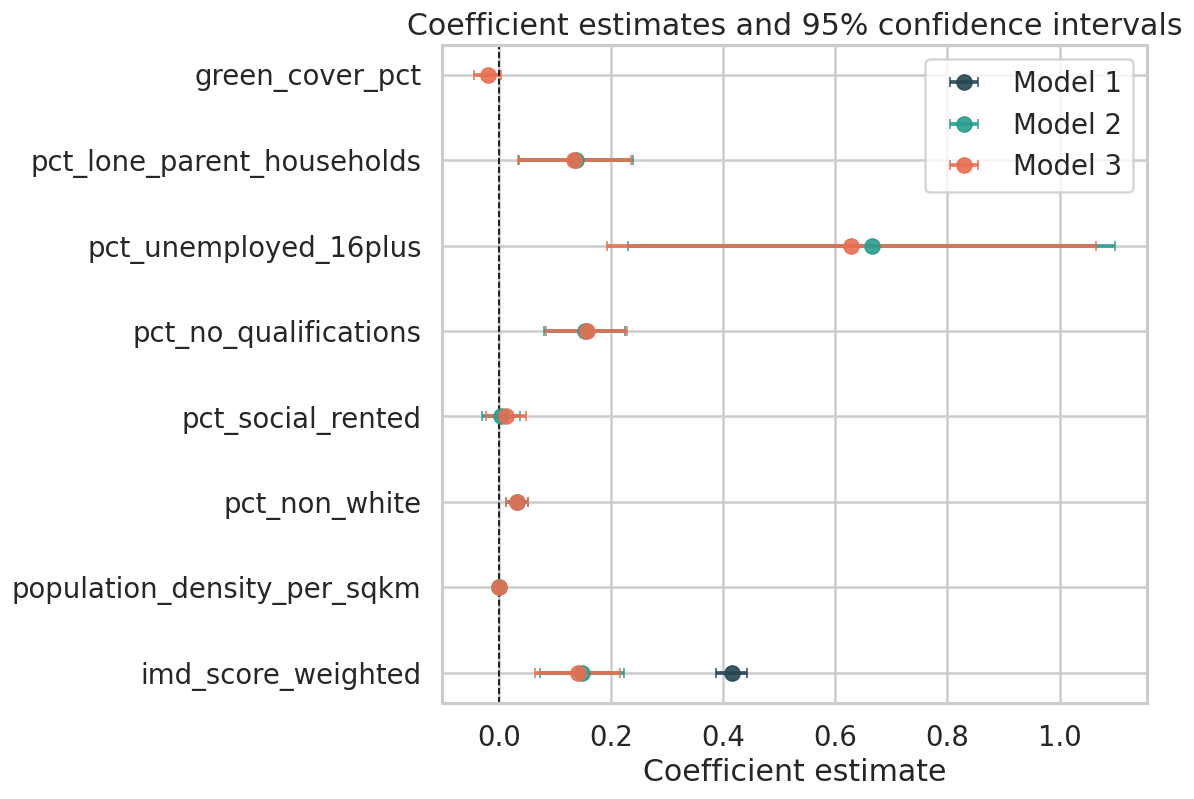

In [12]:
#excluding the intercept
plot_df = tidy_results.loc[tidy_results["term"] != "Intercept"].copy()
#sort terms from top to bottom
plot_df["term"] = pd.Categorical(plot_df["term"], categories=list(reversed(plot_df["term"].unique())), ordered=True)

fig, ax = plt.subplots(figsize=(10, 7))
palette = {"Model 1": "#264653", "Model 2": "#2a9d8f", "Model 3": "#e76f51"}

#plot point estimates and 95% confidence intervals for each hierarchical model
for model_name, sub in plot_df.groupby("model"):
    ax.errorbar(
        x=sub["coef"],
        y=sub["term"],
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high" ] - sub["coef"]],
        fmt="o",
        capsize=3,
        label=model_name,
        color=palette[model_name],
        alpha=0.9,
    )

#add a reference line at zero to identify statistically significant predictors
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Coefficient estimates and 95% confidence intervals")
ax.set_xlabel("Coefficient estimate")
ax.set_ylabel("")
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

The coefficient plot shows that IMD remains positively related with obesity after adjustment, although its effect is reduced.

No qualifications, lone-parent households and especially unemployment remain positively associated with obesity, whereas green cover retains only a weak negative coefficient with limited evidence of an independent effect.


#### 4. Multicollinearity Diagnostics

In [13]:
#calculate VIF to check for multicollinearity among predictors
vif_vars = model_1_vars + model_2_additions + model_3_additions
vif_df = complete_case[vif_vars].copy()
vif_df = sm.add_constant(vif_df)

vif_table = pd.DataFrame({
    "variable": vif_df.columns,
    "vif": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])],
})
#table remove constant and sort by vif values
vif_table = vif_table.loc[vif_table["variable"] != "const"].sort_values("vif", ascending=False).reset_index(drop=True)

display(vif_table.round(3))

,variable,vif
0,imd_score_weighted,8.166
1,pct_social_rented,5.344
2,pct_unemployed_16plus,4.505
3,pct_lone_parent_households,4.244
4,population_density_per_sqkm,3.398
5,pct_no_qualifications,2.933
6,pct_non_white,2.555
7,green_cover_pct,2.438


We can see some overlap among several disadvantage related predictors from the results of variance inflation factor, particularly the IMD score and measures such as social renting, unemployment, and lone-parent households.

However, none of the VIF values exceed conventional thresholds for severe multicollinearity, so the model was kept.

#### 5. Residual Diagnostics for the Preferred Model

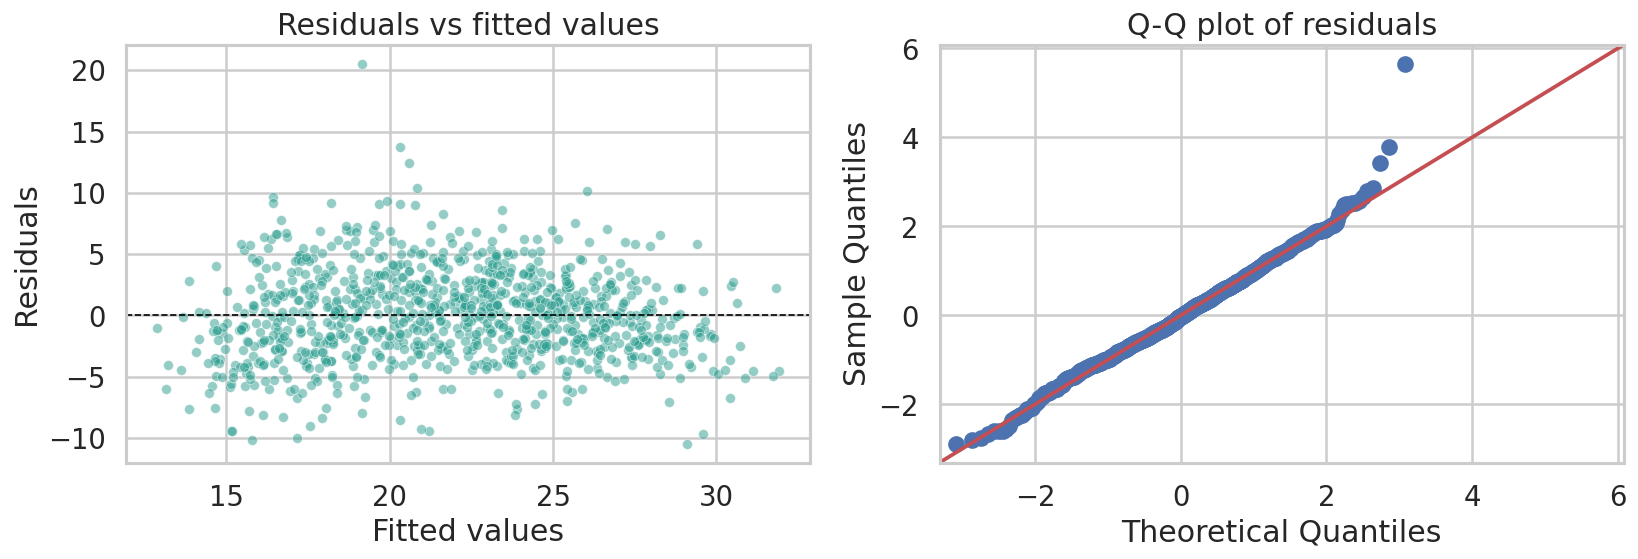

In [14]:
#perform residual analysis on model 3
preferred_model = model_3
diagnostic_df = complete_case.copy()
diagnostic_df["fitted"] = preferred_model.fittedvalues
diagnostic_df["residuals"] = preferred_model.resid
diagnostic_df["std_residuals"] = preferred_model.get_influence().resid_studentized_internal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#check constant variance on left plot
sns.scatterplot(data=diagnostic_df, x="fitted", y="residuals", alpha=0.5, s=35, color="#2a9d8f", ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs fitted values")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

#check for normality of residuals on right plot
sm.qqplot(diagnostic_df["residuals"], line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")

fig.tight_layout()
plt.show()

Residuals are broadly centred around zero by the plotting, with no strong non-linear pattern which supports the use of a linear specification.

Although there are some deviations in the upper tail of  the Q–Q plot, but residuals follow the normal reference line well in the centre of the distribution, so only a small number of outlying.

#### 5.1 Spatial Pattern of Model 3 Residuals

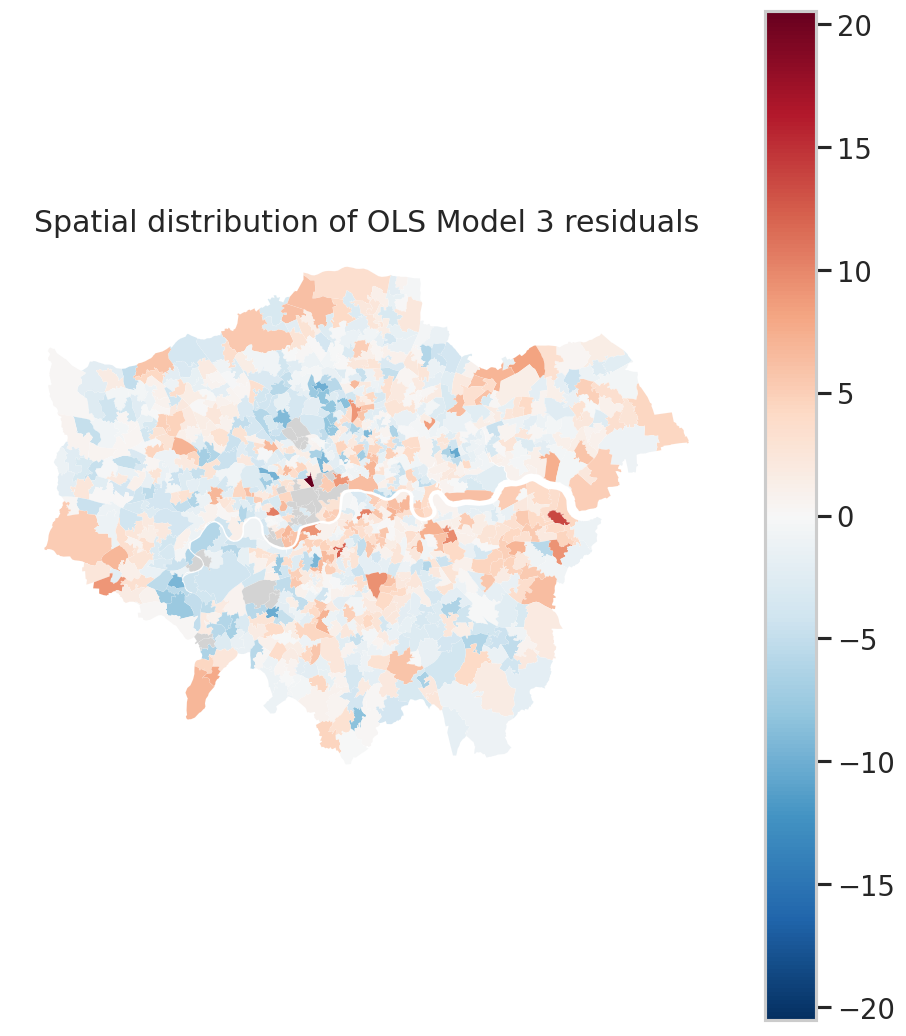

In [15]:
#map the residuals from model 3 to check whether unexplained variation still appears spatially clustered
residual_map = boundary.merge(
    diagnostic_df[["MSOA_code", "residuals"]],
    on="MSOA_code",
    how="left",
)

max_abs_residual = np.nanmax(np.abs(residual_map["residuals"]))

fig, ax = plt.subplots(figsize=(8, 9))
residual_map.plot(
    column="residuals",
    cmap="RdBu_r",
    vmin=-max_abs_residual,
    vmax=max_abs_residual,
    linewidth=0.05,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    ax=ax,
)
ax.set_title("Spatial distribution of OLS Model 3 residuals")
ax.set_axis_off()
fig.tight_layout()
plt.show()

Although much of the remaining error is relatively small and spatially dispersed, some localised clusters of positive and negative residuals are still visible.

In [16]:
#if the required spatial statistics packages are available, estimate Moran's I for the model 3 residuals
try:
    import warnings
    from libpysal.weights import KNN, Queen
    from esda.moran import Moran

    residual_geo = residual_map.dropna(subset=["residuals"]).copy().reset_index(drop=True)

    #use a projected CRS for distance-based fallback weights if needed
    if residual_geo.crs is not None and residual_geo.crs.to_epsg() != 27700:
        residual_geo = residual_geo.to_crs(27700)

    #first try polygon contiguity, which is the most natural choice for areal units
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        queen_weights = Queen.from_dataframe(residual_geo, use_index=False)

    if len(getattr(queen_weights, "islands", [])) == len(residual_geo):
        #if contiguity fails because all areas are treated as islands, fall back to centroid-based KNN weights
        residual_centroids = residual_geo.copy()
        residual_centroids["geometry"] = residual_centroids.geometry.centroid
        weights = KNN.from_dataframe(residual_centroids, k=8)
        weight_type = "KNN (k=8)"
        island_count = len(getattr(weights, "islands", []))
        print("Queen contiguity produced only islands, so Moran's I uses KNN weights instead.")
    else:
        weights = queen_weights
        weight_type = "Queen contiguity"
        island_count = len(getattr(weights, "islands", []))

    weights.transform = "r"
    moran_model3 = Moran(residual_geo["residuals"].values, weights, permutations=999)

    moran_table = pd.DataFrame([
        {
            "statistic": "Moran's I",
            "weight_type": weight_type,
            "n_observations": len(residual_geo),
            "n_islands": island_count,
            "value": moran_model3.I,
            "expected_value": moran_model3.EI,
            "p_value_permutation": moran_model3.p_sim,
            "z_score_permutation": moran_model3.z_sim,
        }
    ]).round(4)

    display(moran_table)

except ModuleNotFoundError:
    print("Moran's I was skipped because libpysal/esda is not installed in the current environment.")
except Exception as exc:
    print("Moran's I could not be computed in the current environment.")
    print(exc)

Queen contiguity produced only islands, so Moran's I uses KNN weights instead.


,statistic,weight_type,n_observations,n_islands,value,expected_value,p_value_permutation,z_score_permutation
0,Moran's I,KNN (k=8),959,0,0.1761,-0.001,0.001,11.4851


Moran's I also proof that there's positive spatial autocorrelation in the residuals.

Because Queen contiguity produced only islands for this geometry, the test was calculated using a centroid-based K-nearest neighbours weights matrix (k=8).

In particular, the model under-predicts or over-predicts obesity prevalence in some areas, means that some neighbourhood-level influences may remain unobserved.

#### 6. Sensitivity Analysis: Replace IMD with IDACI

In [17]:
#a sensitivity analysis that testing if findings are robust using a child-specific deprivation index (IDACI)
sensitivity_vars = [outcome, "idaci_score_weighted"] + sociodemographic_vars + [green_var]
sensitivity_data = model_data.dropna(subset=sensitivity_vars).copy().reset_index(drop=True)

#sensitivity formula
formula_sensitivity = f"{outcome} ~ idaci_score_weighted + {' + '.join(sociodemographic_vars)} + {green_var}"

#fit the model and compare results with the IMD model
model_sensitivity = smf.ols(formula=formula_sensitivity, data=sensitivity_data).fit(cov_type="HC3")
print(model_sensitivity.summary())

#tidy up for easier comparison
sensitivity_tidy = tidy_model(model_sensitivity, "Sensitivity model")
display(sensitivity_tidy.round(4))

                            OLS Regression Results                            
Dep. Variable:        year6_obese_pct   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     158.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          8.19e-169
Time:                        14:05:08   Log-Likelihood:                -2565.5
No. Observations:                 959   AIC:                             5149.
Df Residuals:                     950   BIC:                             5193.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

,term,coef,std_err,p_value,ci_low,ci_high,model
0,Intercept,9.2613,1.0925,0.0000,7.1200,11.4027,Sensitivity model
1,idaci_score_weighted,30.9514,3.6478,0.0000,23.8020,38.1009,Sensitivity model
2,population_density_per_sqkm,0.0001,0.0000,0.0390,0.0000,0.0002,Sensitivity model
3,pct_non_white,0.0399,0.0097,0.0000,0.0208,0.0589,Sensitivity model
4,pct_social_rented,-0.0331,0.0175,0.0580,-0.0673,0.0011,Sensitivity model
5,pct_no_qualifications,0.1735,0.0309,0.0000,0.1130,0.2340,Sensitivity model
6,pct_unemployed_16plus,0.4853,0.2124,0.0223,0.0690,0.9016,Sensitivity model
7,pct_lone_parent_households,0.0518,0.0509,0.3086,-0.0479,0.1515,Sensitivity model
8,green_cover_pct,-0.0182,0.0123,0.1373,-0.0423,0.0058,Sensitivity model


In sensitivity analysis, replacing IMD with IDACI produce similar results, which suggest that the main findings are not sensitive to the deprivation measure used.


#### 7. Comparison Model: Random Forest

To assess whether the relative importance of predictors is generally consistent under a nonlinear setting, random forest regression model is estimated as an assist comparison model.

,model,test_rmse,test_r_squared
0,Random Forest,3.6864,0.4966


,variable,importance_mean,importance_std
0,imd_score_weighted,0.2760,0.0450
1,pct_no_qualifications,0.0746,0.0281
2,pct_unemployed_16plus,0.0368,0.0123
3,population_density_per_sqkm,0.0103,0.0088
4,pct_lone_parent_households,0.0073,0.0138
5,pct_non_white,0.0033,0.0171
6,pct_social_rented,0.0021,0.0053
7,green_cover_pct,-0.0002,0.0105


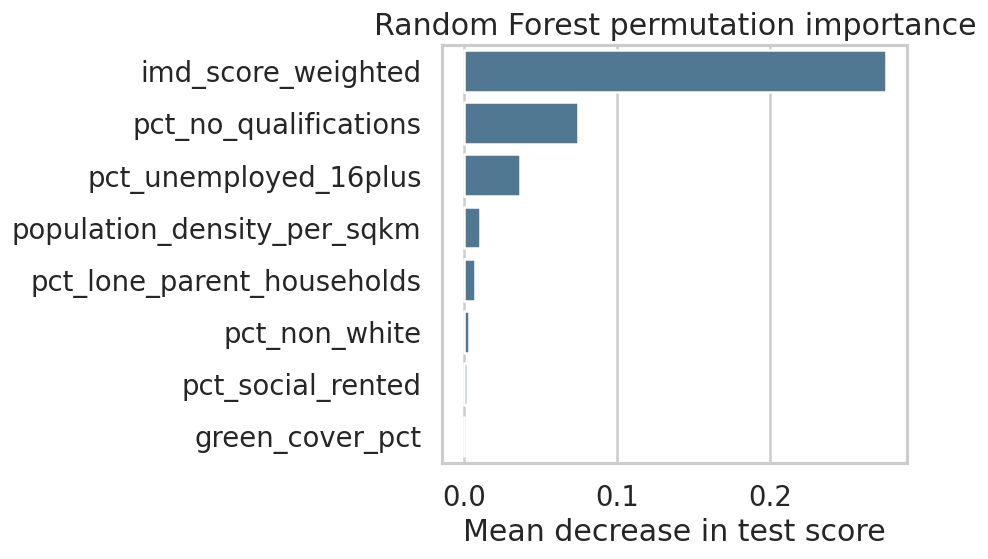

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

rf_vars = model_1_vars + model_2_additions + model_3_additions
rf_data = complete_case[[outcome] + rf_vars].dropna().copy()

X = rf_data[rf_vars]
y = rf_data[outcome]

#split training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

#evaluate model accuracy
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))#calculate root mean squar error

rf_metrics = pd.DataFrame([
    {
        "model": "Random Forest",
        "test_rmse": rmse,
        "test_r_squared": r2_score(y_test, y_pred),
    }
]).round(4)
display(rf_metrics)

#calculate permutation importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=25, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({
    "variable": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(importance_df.round(4))

#show variable importance rank
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df, y="variable", x="importance_mean", color="#457b9d", ax=ax)
ax.set_title("Random Forest permutation importance")
ax.set_xlabel("Mean decrease in test score")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

The random forest model which has better flexibility did not improve predictive performance, and again identified deprivation related variables as the most important predictors rather than green cover.

#### **Limitations**

This project uses cross-sectional data from multiple sources that are not perfectly contemporaneous, so it identifies associations rather than causal effects. Also, MSOA level findings may not apply to individuals.

In addition, Moran's I shows some spatial dependence remains unexplained, suggesting omitted neighbourhood processes or residual spatial structure. Given the word limit and the focus on interpretable baseline association models, spatial regression is left for future work.

Furthermore, the use of `pct_non_white` as a broad measure of ethnic composition is a little rough and does not capture the significant heterogeneity in obesity risks and socio-economic outcomes across different specific ethnic groups.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

In conclusion, Year 6 obesity prevalence is strongly associated with area deprivation, which this relationship is consistent across both the OLS and random forest model. Several indicators of neighbourhood disadvantage, particularly educational disadvantage and unemployment, also retain positive associations with obesity prevalence in the adjusted models.

Although greener areas tend to have lower obesity prevalence, but after adjusting for deprivation and socio-demographic context it does not remain robust. This suggests that the apparent relationship between greener neighbourhoods and lower obesity prevalence is likely to reflect wider neighbourhood conditions.

Overall, the results indicate that deprivation related neighbourhood disadvantage plays a more important role in explaining spatial variation in Year 6 obesity prevalence across London MSOAs, and policies should focus more on wider socioeconomic disadvantage than on green cover alone.

## References

[[ go back to the top ]](#Table-of-contents)

Allison, P.D. (2001) *Missing data*. Thousand Oaks, CA: Sage.

Anselin, L. (2020) *Distance-Band Spatial Weights*. GeoDa Workbook. Available at: https://geodacenter.github.io/workbook/4b_dist_weights/lab4b.html (Accessed: 5 April 2026).

Goisis, A., Martinson, M. and Sigle, W. (2019) ‘When richer doesn’t mean thinner: Ethnicity, socioeconomic position, and the risk of child obesity in the United Kingdom’, *Demographic Research*, 41, pp. 649–678. doi: 10.4054/DemRes.2019.41.23.

Information Centre for Health and Social Care (n.d.) *Prevalence of Childhood Obesity, Borough, Ward and MSOA*. London Datastore. Available at: https://data.london.gov.uk/dataset/prevalence-of-childhood-obesity-borough-ward-and-msoa-23g07/ (Accessed: 1 April 2026).

Kim, J.H. (2019) ‘Multicollinearity and misleading statistical results’, *Korean Journal of Anesthesiology*, 72(6), pp. 558–569. doi: 10.4097/kja.19087.

Mears, M., Brindley, P., Baxter, I., Maheswaran, R. and Jorgensen, A. (2020) ‘Neighbourhood greenspace influences on childhood obesity in Sheffield, UK’, *Pediatric Obesity*, 15(7), e12629. doi: 10.1111/ijpo.12629.

NHS England (2024) *National Child Measurement Programme, England, 2023/24 School Year*. Available at: https://digital.nhs.uk/data-and-information/publications/statistical/national-child-measurement-programme/2023-24-school-year (Accessed: 2 April 2026).

O’Brien, R.M. (2007) ‘A caution regarding rules of thumb for variance inflation factors’, *Quality & Quantity*, 41(5), pp. 673–690. doi: 10.1007/s11135-006-9018-6.

Office for Health Improvement and Disparities (2024) *Obesity Profile: statistical commentary, November 2024*. Available at: https://www.gov.uk/government/statistics/obesity-profile-november-2024-update/obesity-profile-statistical-commentary-november-2024 (Accessed: 1 April 2026).

Sun, Y., Hu, X., Huang, Y. and Chan, T.O. (2020) ‘Spatial patterns of childhood obesity prevalence in relation to socioeconomic factors across England’, *ISPRS International Journal of Geo-Information*, 9(10), p. 599. doi: 10.3390/ijgi9100599.

In [19]:
!jupyter nbconvert --to html --output-dir='.' --output 'notebook.html' "/content/drive/MyDrive/Colab Notebooks/your_notebook_name.ipynb"

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab Notebooks/your_notebook_name.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to